### Monte Carlo Integration


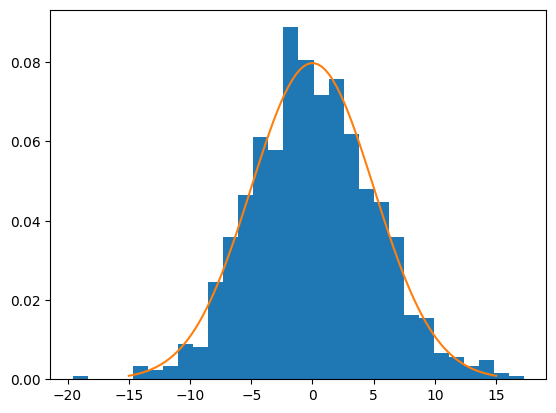

In [18]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
import random
from random import sample


sigma=5 
N=1000
analytic_result=2*sigma**4

gauss = scipy.stats.norm(loc=0,scale=sigma)

plt.hist(gauss.rvs(N),density=True,bins=30);            #N random variable distributed according to the distribution 
plt.plot(np.linspace(-3*sigma,3*sigma,100), gauss.pdf(np.linspace(-3*sigma,3*sigma,100)))


In [19]:
samples = np.abs(gauss.rvs(N))
I = sigma*(np.pi/2)**0.5 * np.mean(samples**3)

print(I,analytic_result, np.abs(I-analytic_result)/analytic_result)

1393.3966456994624 1250 0.11471731655956992


Now let's see how the errors go for different values of N (number of points generated)

In [20]:
m=np.logspace(1.5,6,100,dtype=int)  #in log space from a power of 1.5 to a power of 4

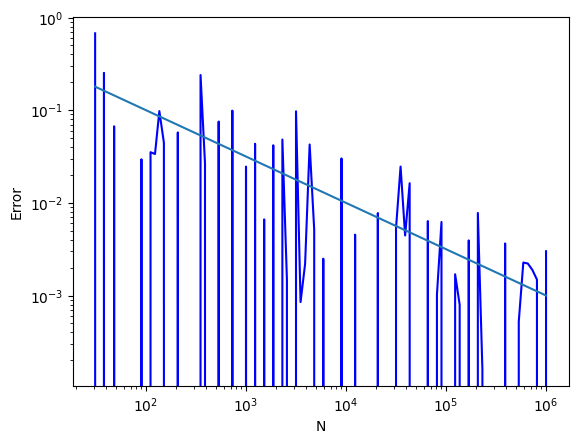

In [22]:
error=[]
for N in m:

    xi=abs(np.random.normal(0,sigma,N)) 
    integral=np.mean(xi**3)/2*np.sqrt(2*np.pi*sigma**2) # calculate the integral
    error.append((integral-analytic_result)/analytic_result)  #relative error
    
plt.plot(m,error, color='b')
plt.loglog()
plt.xlabel('N')
plt.ylabel('Error')
plt.plot(m, m**-0.5)
plt.show()

As expected the relative error go as $1/\sqrt N$

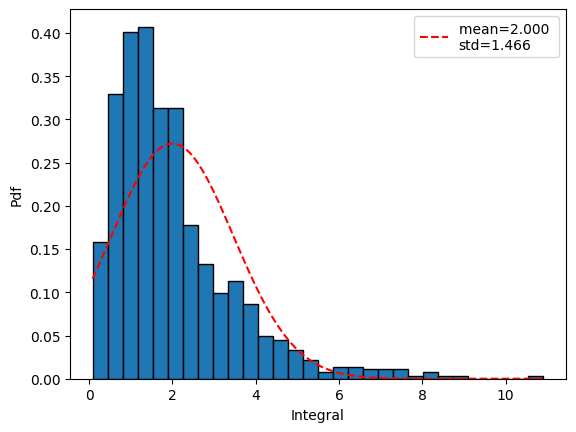

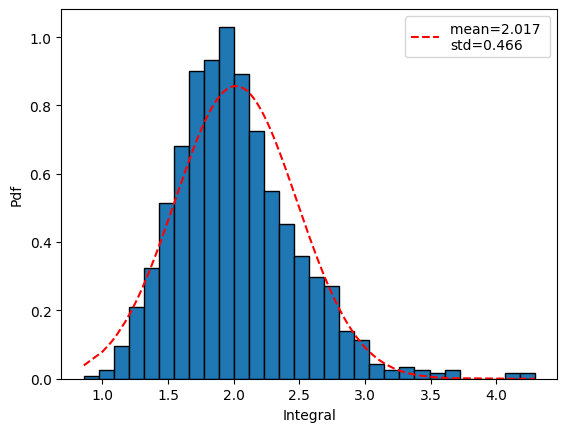

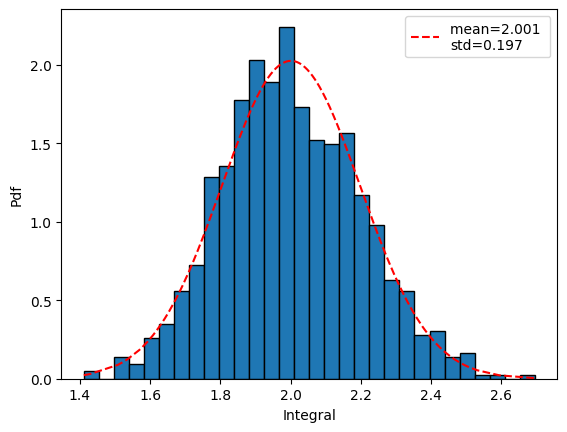

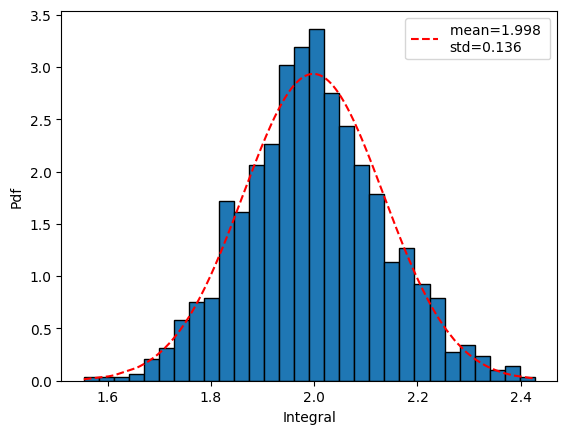

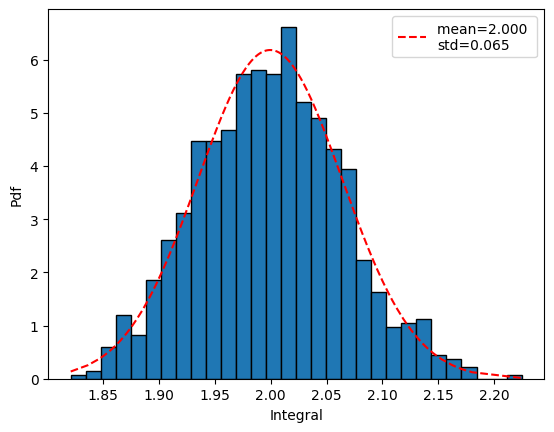

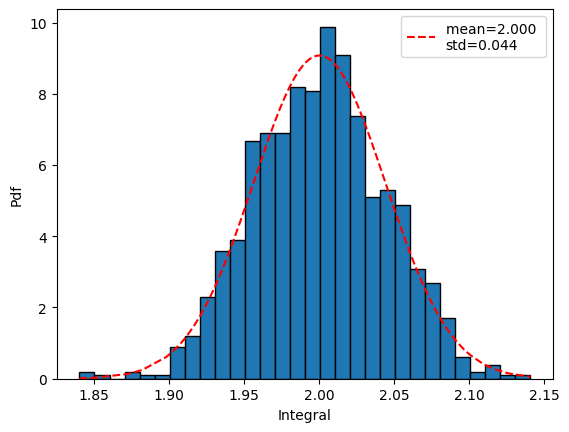

In [71]:
m=np.logspace(1.5,4,100,dtype=int)

A=[10,100,500,1000,5000,10000]
B=[100,500]

def gauss (x, mu, sigma):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu)/sigma)**2)

for x in A:
    integral=[]
    for k in range (0,1000):
        xi=abs(np.random.normal(0,sigma,x)) # generate random numbers from a Gaussian distribution
        integral.append(np.mean(xi**3)/2*np.sqrt(2*np.pi*sigma**2)) # calculate the integral
    plt.hist(integral,bins=30, density=True, edgecolor='black')
    mu=np.mean(integral)
    dev=np.std(integral)
    plt.plot(np.sort(integral),gauss(np.sort(integral),mu,dev),linestyle='--', color='r', label='mean=%.3f \nstd=%.3f'%(mu,dev))
    plt.xlabel('Integral')
    plt.ylabel('Pdf')
    plt.legend()
    plt.show() 
    #plt.xlim(1.2,3.3)


